In [ ]:
# default_exp infoxplainer.ir.eval.x2v

# Evaluation Methods for Software Information Retrieval 

> This module is dedicated to evaluate word2vec/doc2vec or any neural unsupervised approaches on traceability datasets.
> Implementing mutual information analysis
> Author: @danaderp Dec 2020

Software Retrieval can be analyzed in two ways: supervised and unsupervised. 

We employ metrics based on accuracy to evaluate supervised software retrieval:
 - Precision Recall Gain
 - Precision Recall
 - ROC curve
 
We rely on information theory and manifold analysis to evaluate software retrieval unsupervised:
- Information Theory for Software Information Retrieval (Shared Information and Mutual Information)
- Prototypes and Criticisms for Paragraph Vectors 

Check out this methods for causality [links](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6074945/#:~:text=G%20methods%20include%20inverse%20probability,assumptions%20than%20standard%20regression%20methods)

In [97]:
from prg import prg

ModuleNotFoundError: No module named 'prg'

In [16]:
import sys
sys.path.append('../main')

import ds4se as ds
from ds4se.mining.ir import VectorizationType
from ds4se.mining.ir import SimilarityMetric
from ds4se.mining.ir import EntropyMetric

In [3]:
import numpy as np

In [4]:
#??
import gensim
import pandas as pd
from itertools import product 
from random import sample 
import functools 
import os
from enum import Enum, unique, auto

In [5]:
#export
from sklearn.metrics import precision_recall_curve
##from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from pandas.plotting import lag_plot
import math as m
import random as r
import collections
from sklearn.metrics.pairwise import cosine_similarity
##import seaborn as sns

In [6]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html
#export
from scipy.spatial import distance
from scipy.stats import pearsonr
import scipy as sc

In [7]:
#export
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

In [8]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## Loading Experiments

In [ ]:
#baseline experiment
experiment = 'experiments0.0.x/'
path_data = '../dvc-ds4se/metrics/traceability/' + experiment 
def libest_params():
    return{
        "experiment_path_w2v": path_data + '[libest-VectorizationType.word2vec-LinkType.req2tc-True-1608690009.09251].csv',
        "experiment_path_d2v": path_data + '[libest-VectorizationType.doc2vec-LinkType.req2tc-True-1608686014.751808].csv'
    }   

In [ ]:
###########

In [ ]:
#experiment 0.0.0/1
experiment = 'experiments0.0.x/'
path_data = '../dvc-ds4se/metrics/traceability/' + experiment 
def libest_params():
    return{
        "system": 'libest',
        "experiment_path_w2v": path_data + '[libest-VectorizationType.word2vec-LinkType.req2tc-True-1609292406.653621].csv',
        "experiment_path_d2v": path_data + '[libest-VectorizationType.doc2vec-LinkType.req2tc-True-1609289141.142806].csv'
    }   

In [ ]:
#experiment 0.0.2/3
experiment = 'experiments0.0.x/'
path_data = '../dvc-ds4se/metrics/traceability/' + experiment 
def sacp_params():
    return{
        "system": 'sacp',
        "experiment_path_w2v": path_data + '[sacp-python-common-VectorizationType.word2vec-LinkType.issue2src-True-1608725764.813377].csv',
        "experiment_path_d2v": path_data + '[sacp-python-common-VectorizationType.doc2vec-LinkType.issue2src-True-1608688791.757431].csv',
        'saving_path': '../../'+'data/cisco/sacp_data/',
        'system_long': 'sacp-python-common',
        'timestamp': 1595953540.866044,
        'language': 'all-corpus'
    }  

In [33]:
#experiment 4.0.0/1
path_data = '../dvc-data/systems/dronology/' 
def dronology_params():
    return{
        "system": 'dronology',
        "experiment_path_w2v": path_data + 'experiment4.0.0/results/[dronology-VectorizationType.word2vec-LinkType.req2src-True-1752436082].csv',
        "experiment_path_d2v": path_data + 'experiment4.0.1/results/dronology_doc2vec_all_with_labels_20250623132856.csv',
        'saving_path': '../dvc-data/systems/dronology/corpus/',
        'system_long': 'dronology',
        'timestamp': 1595953540.866044,
        'language': 'all-corpus'
    } 

In [36]:
#params = libest_params()
#params = sacp_params()
params = dronology_params()

params['experiment_path_w2v']

'../dvc-data/systems/dronology/experiment4.0.0/results/[dronology-VectorizationType.word2vec-LinkType.req2src-True-1752436082].csv'

In [ ]:
#experiment 1.0.0/1
experiment = 'experiments1.0.x/'
path_data = '../dvc-ds4se/metrics/traceability/' + experiment 
def libest_params():
    return{
        "experiment_path_w2v": path_data + '[libest-VectorizationType.word2vec-LinkType.req2tc-True-1608759050.647883].csv',
        "experiment_path_d2v": path_data + '[libest-VectorizationType.doc2vec-LinkType.req2tc-True-1608690752.27334].csv'
    }   

In [ ]:
#experiment 1.0.2/3
experiment = 'experiments1.0.x/'
path_data = '../dvc-ds4se/metrics/traceability/' + experiment 
def sacp_params():
    return{
        "experiment_path_w2v": path_data + '[sacp-python-common-VectorizationType.word2vec-LinkType.issue2src-True-1609287807.786373].csv',
        "experiment_path_d2v": path_data + '[sacp-python-common-VectorizationType.doc2vec-LinkType.issue2src-True-1609009631.599384].csv'
    }   

#  Data Science Evaluation
Classification/evaluation metrics for highly imbalanced data [(see Forum)](https://stats.stackexchange.com/questions/222558/classification-evaluation-metrics-for-highly-imbalanced-data).

In [11]:
%matplotlib inline

In [39]:
#export
class VectorEvaluation():
    '''Approaches Common Evaluations and Interpretations (statistical analysis)
       Loading unsupervised results
       w2v includes entropy evaluation
    '''
    def __init__(self, params):
        self.params = params
        self.df_w2v = pd.read_csv(params['experiment_path_w2v'], header=0, index_col=0, sep=',')
        self.df_d2v = pd.read_csv(params['experiment_path_d2v'], header=0, index_col=0, sep=',')

        self.sim_list_w2v = [SimilarityMetric.SCM_sim, SimilarityMetric.WMD_sim]
        self.sim_list_d2v = [SimilarityMetric.COS_sim , SimilarityMetric.EUC_sim]
        
        
        
        #Entropy
        manifoldEntropy =  self.sim_list_w2v + [EntropyMetric.Entropy_src, EntropyMetric.Entropy_tgt, 
                           EntropyMetric.JI, EntropyMetric.MI, EntropyMetric.Loss, 
                           EntropyMetric.Noise]
        manifoldEntropy = [str(i) for i in manifoldEntropy] + ['Linked?']
        self.manifoldEntropy = self.df_w2v[manifoldEntropy].copy()

        ##Concat D2V
        for i in self.sim_list_d2v:
            self.manifoldEntropy[ str(i) ] = self.df_d2v[str(i)].values
        
        self.manifoldEntropy = self.manifoldEntropy[~self.manifoldEntropy.isin([np.nan, np.inf, -np.inf]).any(axis=1)]
        
        #SharedInfo
        sharedInfo = self.sim_list_w2v +[EntropyMetric.MSI_I,EntropyMetric.MSI_X]
        sharedInfo = [str(i) for i in sharedInfo] + ['Linked?']
        self.sharedInfo = self.df_w2v[sharedInfo].copy()
        
        for i in self.sim_list_d2v:
            self.sharedInfo[ str(i) ] = self.df_d2v[ str(i) ].values #No filtered by nans
            
        self.df_sys = self.LoadCorpus(params['timestamp'], language=params['language'], sep='~')
            
    def LoadCorpus(self, timestamp, language='js', sep=',', mode='a'):
        path_to_link = '../dvc-data/systems/dronology/corpus/dronology_conv_with_bpe_fixed.csv'
        return pd.read_csv(path_to_link, header=0, index_col=0, sep=sep)

In [40]:
#tst
test_vector_eval = VectorEvaluation(params)

In [41]:
#tst
test_vector_eval.df_w2v.shape

(10672, 16)

In [42]:
#tst 
test_vector_eval.df_d2v.shape

(10672, 8)

In [48]:
test_vector_eval.df_w2v.reset_index(drop=True, inplace=True)
test_vector_eval.df_d2v.reset_index(drop=True, inplace=True)

In [49]:
assert (
    test_vector_eval.df_w2v['Source'].iat[0]
    == test_vector_eval.df_d2v['Source'].iat[0]
)

KeyError: 'Source'

In [45]:
assert test_vector_eval.df_w2v.Target[0] == test_vector_eval.df_d2v.Target[0]

/var/folders/5h/n5m0pqsj0c99d6njrjq2rffr0000gn/T/ipykernel_73053/1397052145.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert test_vector_eval.df_w2v.Target[0] == test_vector_eval.df_d2v.Target[0]


In [46]:
assert test_vector_eval.df_w2v.Source[1091] == test_vector_eval.df_d2v.Source[1091]

AttributeError: 'DataFrame' object has no attribute 'Source'

In [50]:
assert test_vector_eval.df_w2v.Target[1091] == test_vector_eval.df_d2v.Target[1091]

In [51]:
#tst
test_vector_eval.manifoldEntropy

,SimilarityMetric.SCM_sim,SimilarityMetric.WMD_sim,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?,SimilarityMetric.COS_sim,SimilarityMetric.EUC_sim
Source,,,,,,,,,,,
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.048474,0.447275,3.773557,6.141791,6.213403,3.701945,2.439846,0.071612,0,0.031171,0.041098
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.440566,3.773557,5.446458,5.689563,3.530453,1.916006,0.243105,0,0.142615,0.047802
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.432349,3.773557,4.074090,4.642173,3.205473,0.868616,0.568084,0,-0.045248,0.051505
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.093173,0.453233,3.773557,6.500586,6.589967,3.684176,2.816410,0.089381,0,0.018693,0.038733
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.437537,3.773557,4.403574,4.958147,3.218984,1.184590,0.554573,0,-0.088919,0.066658
...,...,...,...,...,...,...,...,...,...,...,...
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.023290,0.451384,3.584184,4.803804,5.276423,3.111565,1.692239,0.472619,0,0.244839,0.081391
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.040295,0.448870,3.584184,5.260576,5.536220,3.308540,1.952037,0.275644,0,0.352989,0.054770
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.188580,0.471674,3.584184,6.724573,6.756120,3.552637,3.171936,0.031547,0,0.335409,0.034263


In [52]:
#tst
test_vector_eval.sharedInfo

,SimilarityMetric.SCM_sim,SimilarityMetric.WMD_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,Linked?,SimilarityMetric.COS_sim,SimilarityMetric.EUC_sim
Source,,,,,,,
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.048474,0.447275,1.921928,1.214807,0,0.031171,0.041098
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.440566,NaN,NaN,0,0.142615,0.047802
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.432349,NaN,NaN,0,-0.045248,0.051505
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.093173,0.453233,1.500000,1.122556,0,0.018693,0.038733
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,0.000000,0.437537,NaN,NaN,0,-0.088919,0.066658
...,...,...,...,...,...,...,...
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.023290,0.451384,0.000000,0.000000,0,0.244839,0.081391
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.040295,0.448870,0.000000,0.000000,0,0.352989,0.054770
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-551.txt,0.188580,0.471674,2.197160,1.256062,0,0.335409,0.034263


In [53]:
#Sys
test_vector_eval.df_sys.head(2)

,filenames,text,type,conv,bpe8k,bpe32k,bpe128k
ids,,,,,,,
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,RE-616.txt,[SUMMARY]\nLogging of GCS related events\n[DES...,req,summari log gcs relat event descript activ log...,▁sum m ari ▁log ▁g cs ▁rel at ▁event ▁descri p...,▁sum m ari ▁log ▁g cs ▁rel at ▁event ▁descri p...,▁summ ari ▁log ▁gcs ▁relat ▁event ▁descri pt ▁...
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-574.txt,RE-574.txt,[SUMMARY]\nSupport for GCS connected UAVs\n[DE...,req,summari support gcs connect uav descript vehic...,▁sum m ari ▁support ▁g cs ▁connect ▁u av ▁desc...,▁sum m ari ▁support ▁g cs ▁connect ▁u av ▁desc...,▁summ ari ▁support ▁gcs ▁connect ▁u av ▁descri...


## EDA for Interpretability

In [54]:
## Confidence Intervals Self-Information
#TODO add in to a class
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), sc.stats.sem(a)
    h = se * sc.stats.t.ppf((1 + confidence) / 2., n-1)
    return round(m,2), round(m-h,2), round(m+h,2), round(h,2)

In [55]:
#Source self Entropy
mean_confidence_interval(test_vector_eval.manifoldEntropy['EntropyMetric.Entropy_src'].values)

(3.48, 3.47, 3.49, 0.01)

In [56]:
#Target Self Entropy
mean_confidence_interval(test_vector_eval.manifoldEntropy['EntropyMetric.Entropy_tgt'].values)

(5.23, 5.22, 5.25, 0.01)

In [57]:
#Mutual information
mean_confidence_interval(test_vector_eval.manifoldEntropy['EntropyMetric.MI'].values)

(3.2, 3.19, 3.21, 0.01)

In [58]:
#Loss
mean_confidence_interval(test_vector_eval.manifoldEntropy['EntropyMetric.Loss'].values)

(2.03, 2.02, 2.04, 0.01)

In [59]:
#Noise
mean_confidence_interval(test_vector_eval.manifoldEntropy['EntropyMetric.Noise'].values)

(0.28, 0.28, 0.28, 0.0)

In [60]:
#export
class ExploratoryDataSoftwareAnalysis(VectorEvaluation):
    def __init__(self, params):
        super().__init__(params)

In [61]:
EDA = ExploratoryDataSoftwareAnalysis( params = params ) #<---- Parameter 

In [62]:
EDA.df_w2v.describe().round(2)

,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?
count,10672.00,10672.00,10672.00,10672.00,7718.00,7718.00,10672.00,10672.00,10672.00,10672.00,10672.00,10672.00,10672.00
mean,1.23,0.45,0.94,0.06,0.83,0.63,3.48,5.23,5.51,3.20,2.03,0.28,0.04
std,0.07,0.02,0.08,0.08,0.82,0.54,0.33,0.75,0.57,0.35,0.64,0.21,0.19
min,0.72,0.42,0.32,0.00,0.00,0.00,2.63,3.17,3.84,1.95,0.50,0.00,0.00
25%,1.20,0.44,0.92,0.01,0.00,0.00,3.24,4.69,5.08,2.97,1.55,0.12,0.00
50%,1.25,0.44,0.97,0.03,0.92,0.92,3.48,5.25,5.47,3.19,1.97,0.22,0.00
75%,1.28,0.45,0.99,0.08,1.50,1.12,3.68,5.77,5.91,3.43,2.46,0.40,0.00
max,1.37,0.58,1.00,0.68,3.53,1.37,4.22,7.01,7.05,4.18,4.40,1.55,1.00


In [63]:
EDA.df_w2v[EDA.df_w2v['Linked?']== 1].describe().round(2)

,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?
count,393.00,393.00,393.00,393.00,355.00,355.00,393.00,393.00,393.00,393.00,393.00,393.00,393.0
mean,1.15,0.47,0.83,0.17,1.53,1.00,3.53,5.40,5.61,3.32,2.08,0.21,1.0
std,0.12,0.03,0.15,0.15,0.83,0.42,0.27,0.78,0.62,0.29,0.68,0.21,0.0
min,0.77,0.43,0.38,0.00,0.00,0.00,2.63,3.17,4.37,2.35,0.53,0.00,1.0
25%,1.09,0.44,0.74,0.05,1.00,1.00,3.39,4.85,5.13,3.14,1.57,0.07,1.0
50%,1.19,0.46,0.88,0.12,1.58,1.17,3.46,5.39,5.53,3.31,2.02,0.14,1.0
75%,1.25,0.48,0.95,0.26,2.16,1.25,3.62,6.00,6.08,3.48,2.58,0.27,1.0
max,1.35,0.56,1.00,0.62,3.42,1.37,4.22,7.01,7.03,4.13,3.80,1.38,1.0


In [64]:
EDA.df_w2v[EDA.df_w2v['Linked?']== 0].describe().round(2)

,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?
count,10279.00,10279.00,10279.00,10279.00,7363.00,7363.00,10279.00,10279.00,10279.00,10279.00,10279.00,10279.00,10279.0
mean,1.23,0.45,0.94,0.06,0.80,0.61,3.48,5.23,5.51,3.19,2.03,0.28,0.0
std,0.07,0.01,0.08,0.08,0.80,0.54,0.33,0.74,0.57,0.35,0.63,0.21,0.0
min,0.72,0.42,0.32,0.00,0.00,0.00,2.63,3.17,3.84,1.95,0.50,0.01,0.0
25%,1.20,0.44,0.92,0.01,0.00,0.00,3.24,4.69,5.08,2.96,1.55,0.12,0.0
50%,1.25,0.44,0.97,0.03,0.92,0.92,3.50,5.24,5.47,3.19,1.97,0.22,0.0
75%,1.28,0.45,0.99,0.08,1.50,1.12,3.68,5.77,5.90,3.43,2.45,0.40,0.0
max,1.37,0.58,1.00,0.68,3.53,1.37,4.22,7.01,7.05,4.18,4.40,1.55,0.0


In [65]:
EDA.df_d2v.describe().round(2)

,DistanceMetric.EUC,SimilarityMetric.EUC_sim,DistanceMetric.COS,SimilarityMetric.COS_sim,DistanceMetric.MAN,SimilarityMetric.MAN_sim,Linked?
count,10672.00,10672.00,10672.00,10672.00,10672.00,10672.00,10672.00
mean,18.37,0.06,0.83,0.17,327.18,0.00,0.04
std,6.93,0.02,0.15,0.15,122.91,0.00,0.19
min,3.21,0.02,0.27,-0.40,57.65,0.00,0.00
25%,12.84,0.04,0.73,0.07,228.96,0.00,0.00
50%,17.65,0.05,0.83,0.17,315.04,0.00,0.00
75%,22.81,0.07,0.93,0.27,405.84,0.00,0.00
max,39.89,0.24,1.40,0.73,712.90,0.02,1.00


array([[<Axes: xlabel='SimilarityMetric.SCM_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.WMD_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.Entropy_src', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.Entropy_tgt', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.JI', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.MI', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.Loss', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.Noise', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='Linked?', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.COS_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.EUC_sim', ylabel='SimilarityMetric.SCM_sim'>],
       [<Axes: xlabel='SimilarityMetric.SCM_sim', ylabel='SimilarityMetric.WMD_sim'>,
        <

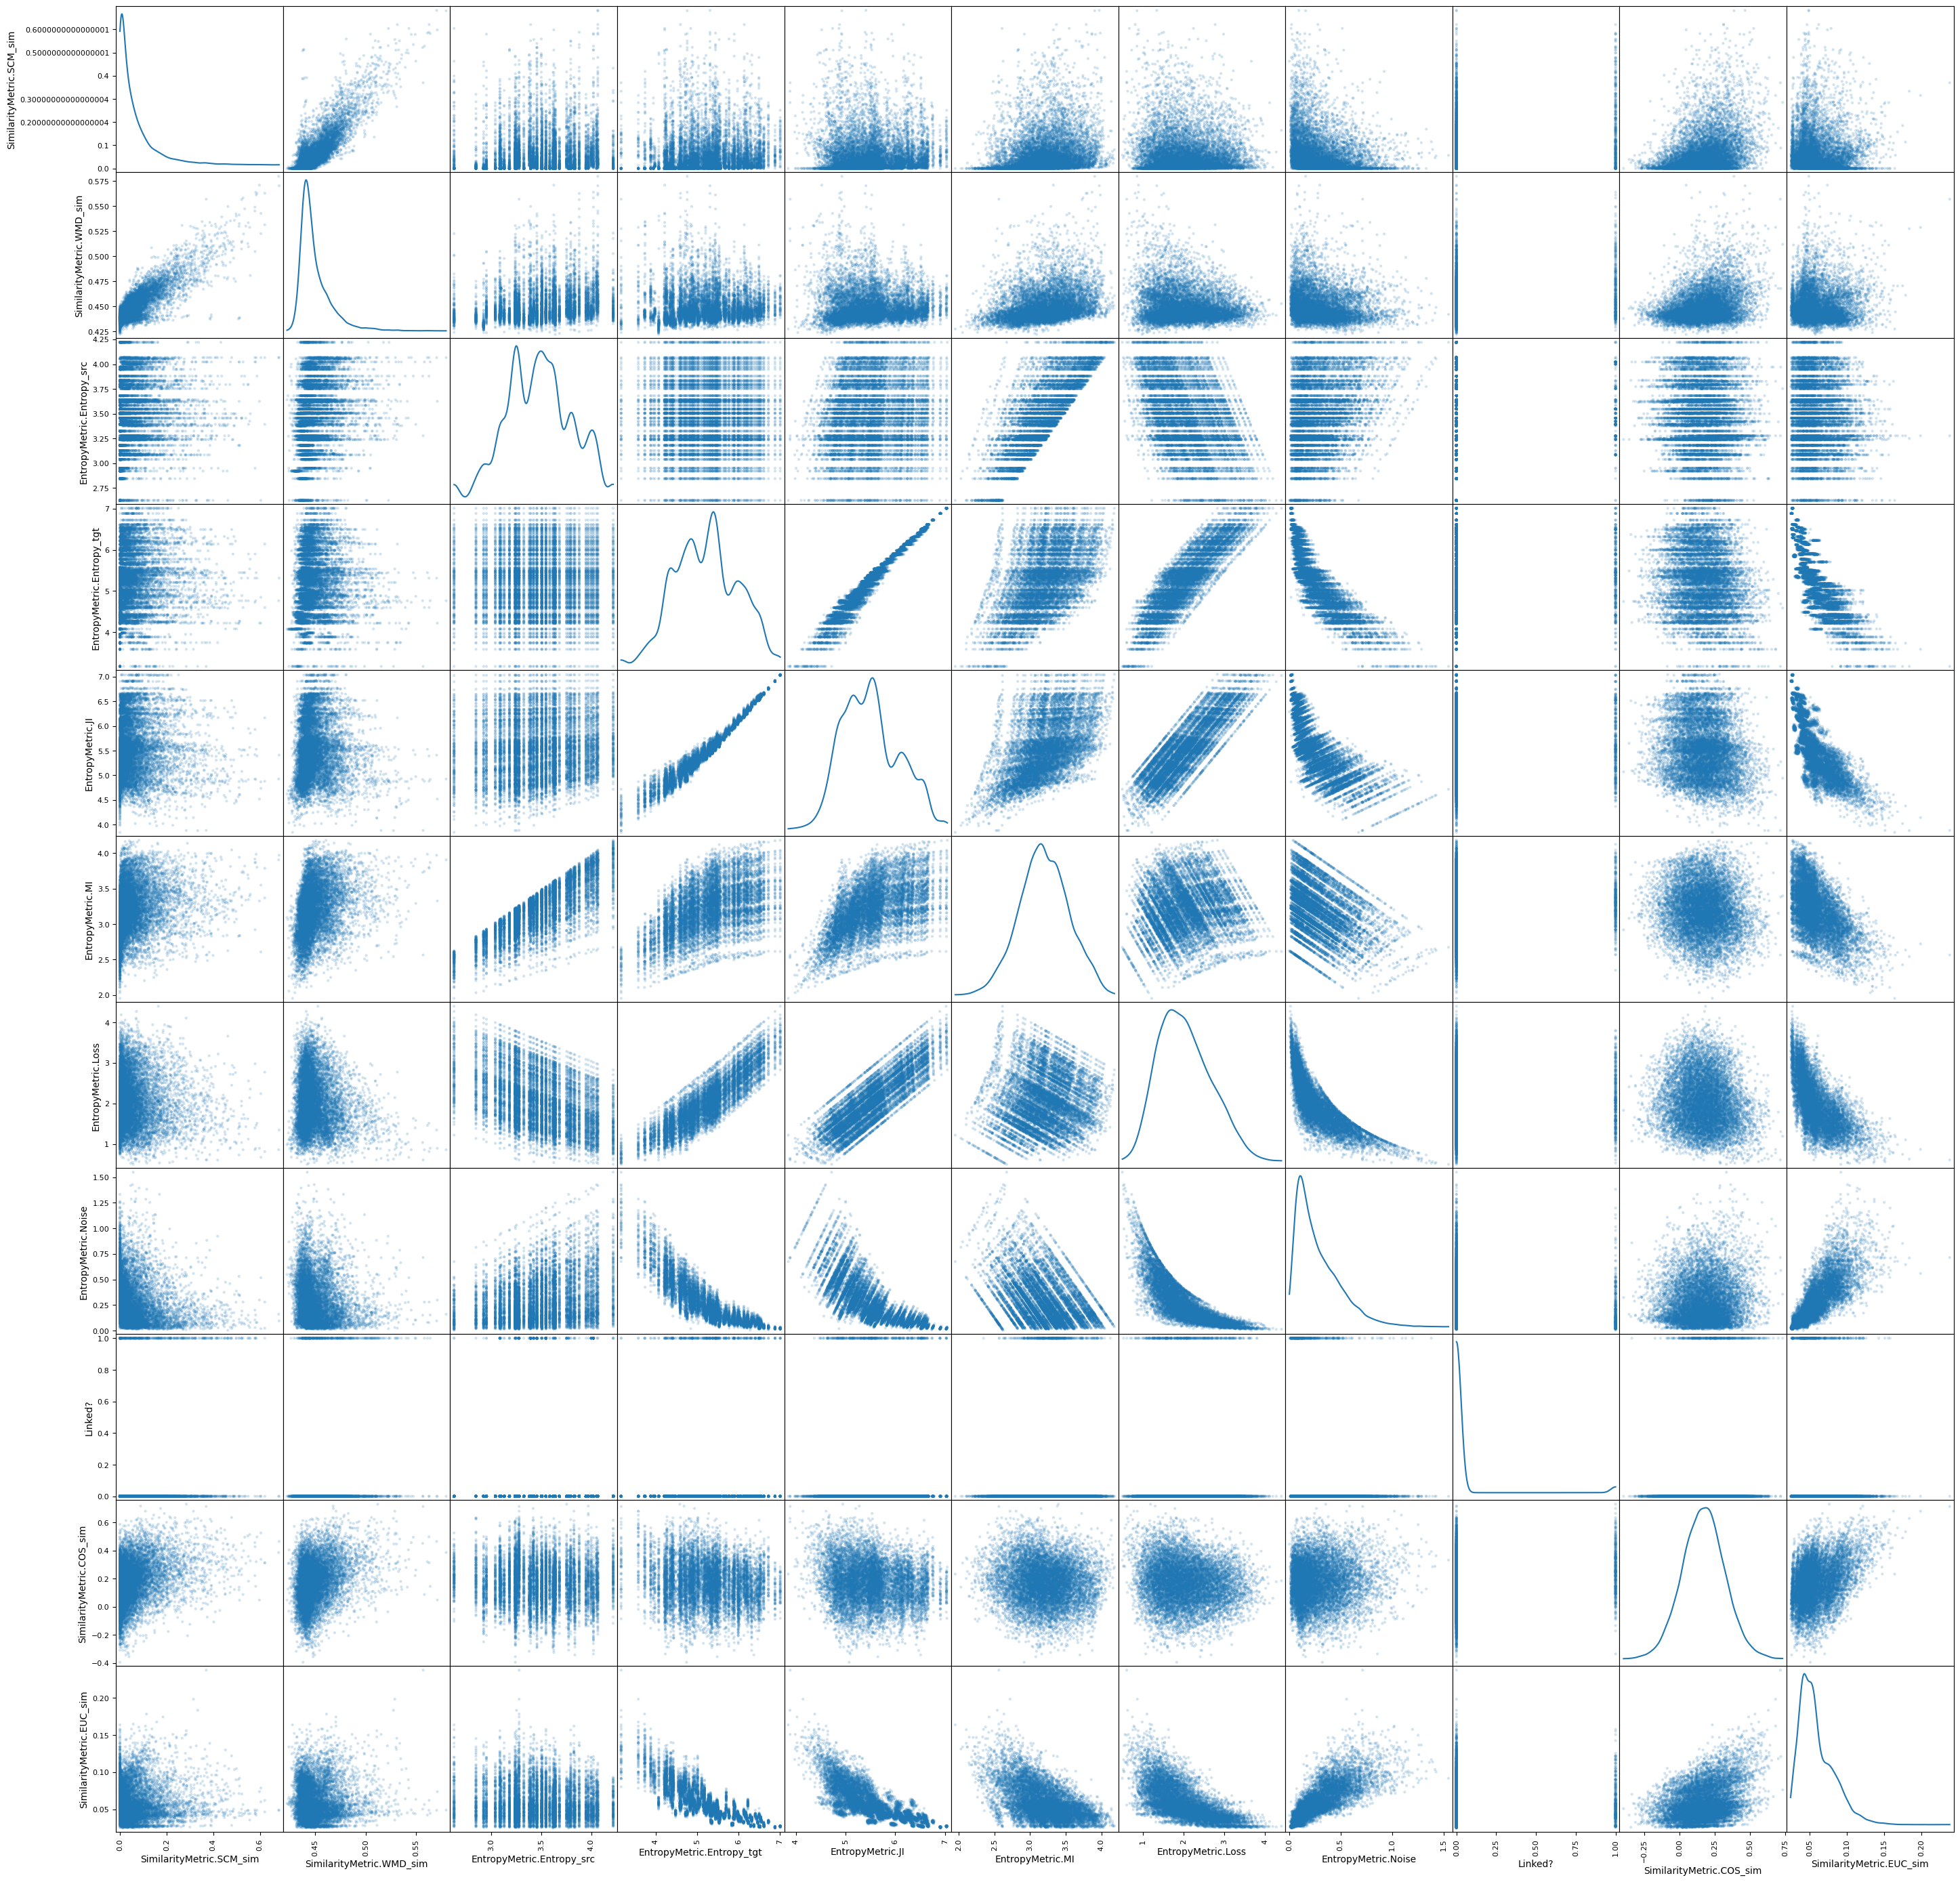

In [66]:
scatter_matrix(EDA.manifoldEntropy, alpha=0.2, figsize=(35, 35), diagonal='kde')

array([[<Axes: xlabel='SimilarityMetric.SCM_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.WMD_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.MSI_I', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='EntropyMetric.MSI_X', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='Linked?', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.COS_sim', ylabel='SimilarityMetric.SCM_sim'>,
        <Axes: xlabel='SimilarityMetric.EUC_sim', ylabel='SimilarityMetric.SCM_sim'>],
       [<Axes: xlabel='SimilarityMetric.SCM_sim', ylabel='SimilarityMetric.WMD_sim'>,
        <Axes: xlabel='SimilarityMetric.WMD_sim', ylabel='SimilarityMetric.WMD_sim'>,
        <Axes: xlabel='EntropyMetric.MSI_I', ylabel='SimilarityMetric.WMD_sim'>,
        <Axes: xlabel='EntropyMetric.MSI_X', ylabel='SimilarityMetric.WMD_sim'>,
        <Axes: xlabel='Linked?', ylabel='SimilarityMetric.WMD_sim'>,
        <Axes: xlabel

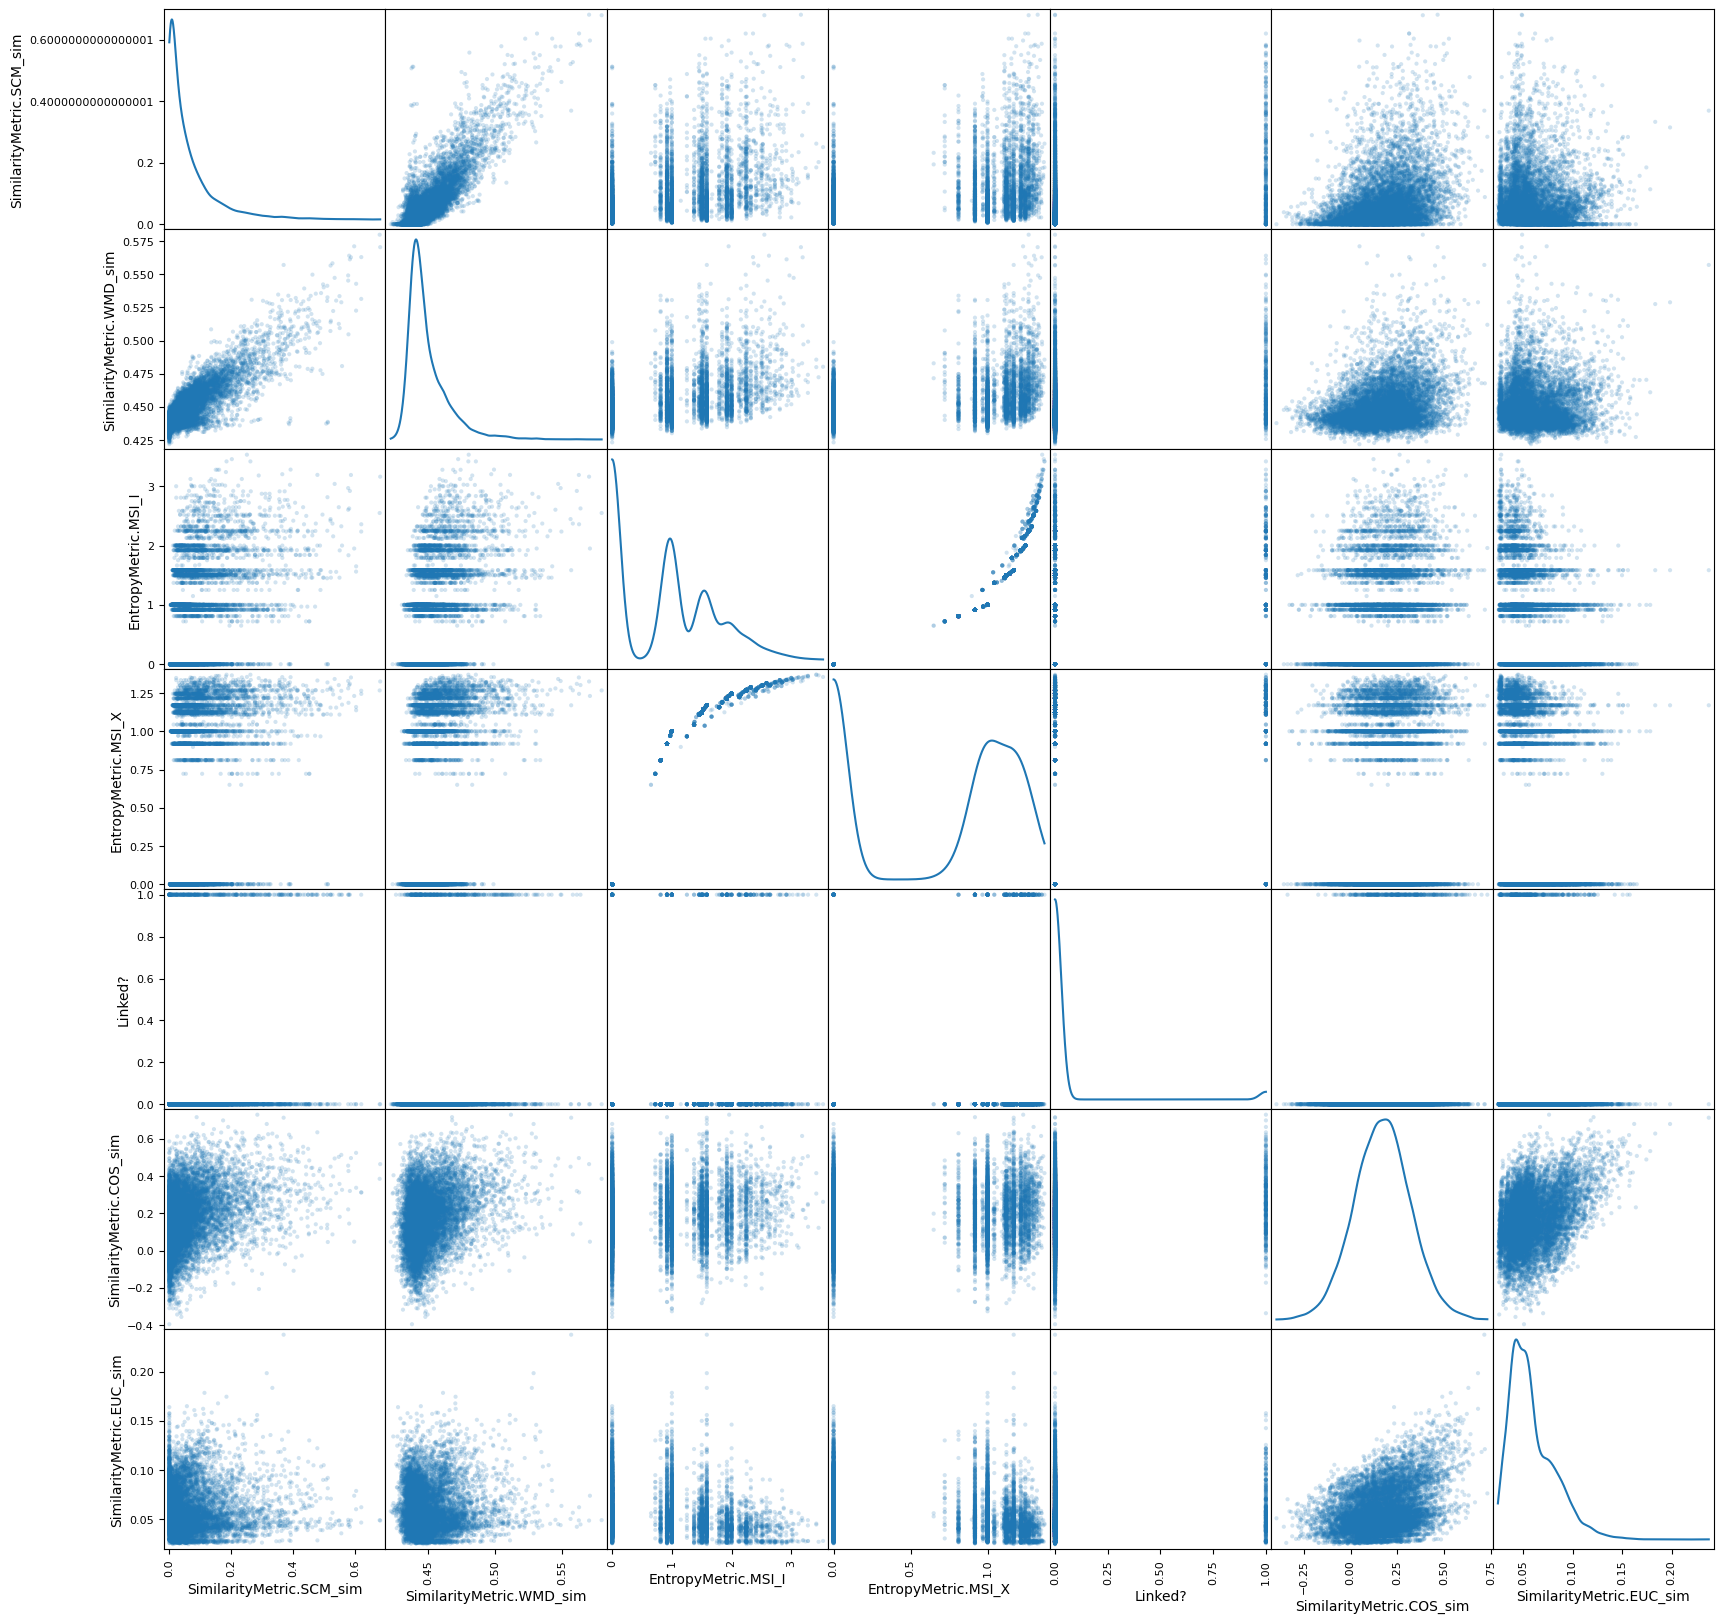

In [67]:
scatter_matrix(EDA.sharedInfo, alpha=0.2, figsize=(20, 20), diagonal='kde')

Lag plots are used to check if a data set or time series is random. Random data should not exhibit any structure in the lag plot. Non-random structure implies that the underlying data are not random. The lag argument may be passed, and when lag=1 the plot is essentially data[:-1] vs. data[1:].

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

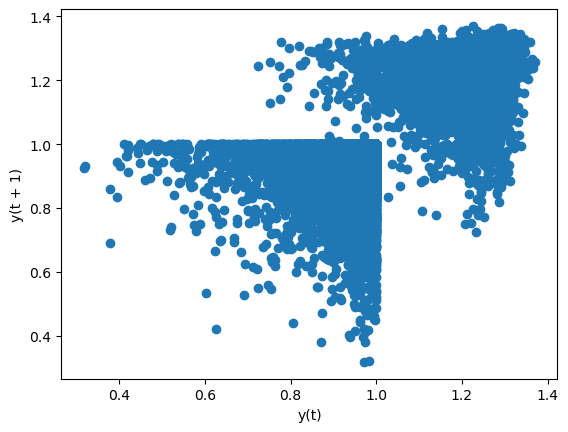

In [68]:
lag_plot( EDA.df_w2v[['DistanceMetric.WMD','DistanceMetric.SCM']] )

array([[<Axes: title={'center': 'SimilarityMetric.SCM_sim'}>,
        <Axes: title={'center': 'SimilarityMetric.WMD_sim'}>,
        <Axes: title={'center': 'EntropyMetric.Entropy_src'}>],
       [<Axes: title={'center': 'EntropyMetric.Entropy_tgt'}>,
        <Axes: title={'center': 'EntropyMetric.JI'}>,
        <Axes: title={'center': 'EntropyMetric.MI'}>],
       [<Axes: title={'center': 'EntropyMetric.Loss'}>,
        <Axes: title={'center': 'EntropyMetric.Noise'}>,
        <Axes: title={'center': 'Linked?'}>],
       [<Axes: title={'center': 'SimilarityMetric.COS_sim'}>,
        <Axes: title={'center': 'SimilarityMetric.EUC_sim'}>, <Axes: >]],
      dtype=object)

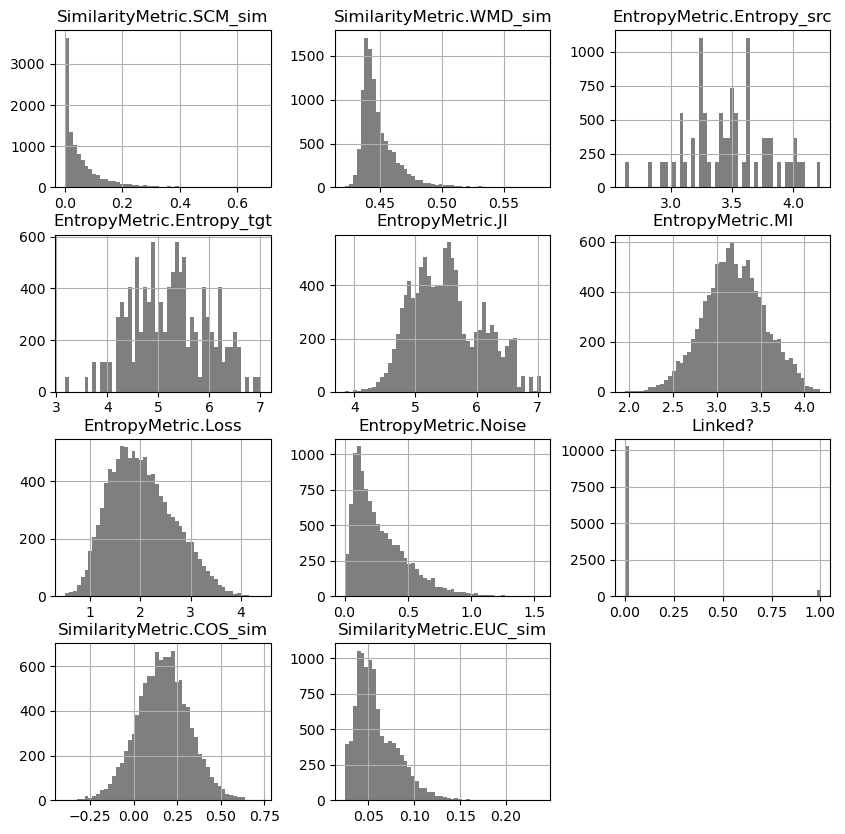

In [69]:
EDA.manifoldEntropy.hist(color='k', bins=50, figsize=[10,10], alpha=0.5)

array([[<Axes: title={'center': 'SimilarityMetric.SCM_sim'}>,
        <Axes: title={'center': 'SimilarityMetric.WMD_sim'}>,
        <Axes: title={'center': 'EntropyMetric.MSI_I'}>],
       [<Axes: title={'center': 'EntropyMetric.MSI_X'}>,
        <Axes: title={'center': 'Linked?'}>,
        <Axes: title={'center': 'SimilarityMetric.COS_sim'}>],
       [<Axes: title={'center': 'SimilarityMetric.EUC_sim'}>, <Axes: >,
        <Axes: >]], dtype=object)

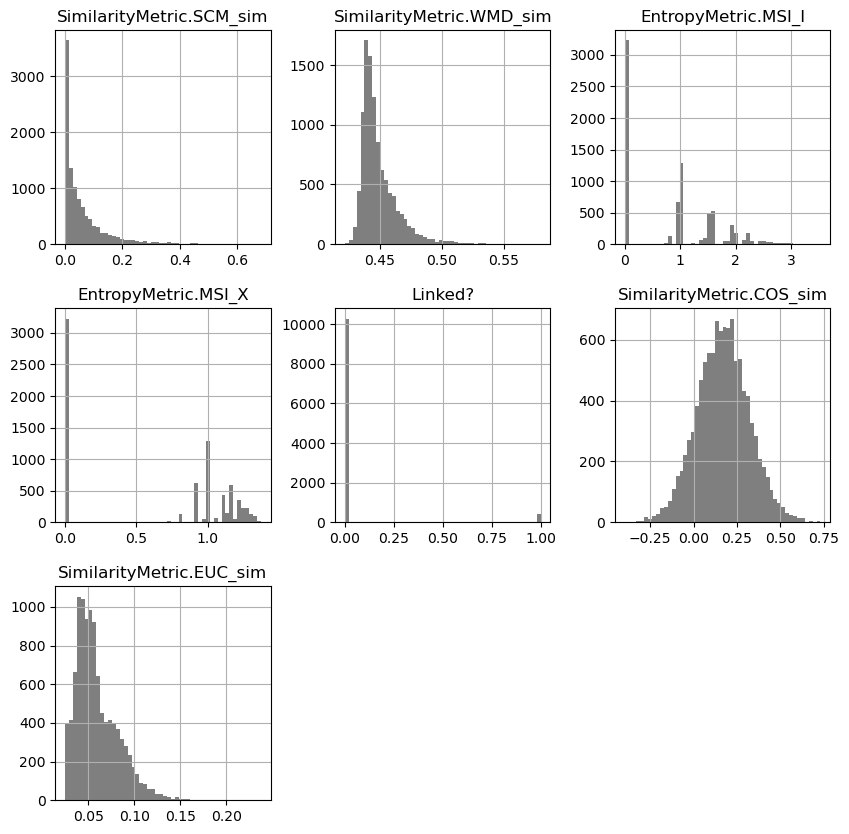

In [70]:
EDA.sharedInfo.hist(color='k', bins=50, figsize=[10,10], alpha=0.5)

In [71]:
##EDA.df_w2v[column_w2v].plot.kde()

In [72]:
##EDA.df_w2v[column_w2v].plot.hist(density=True) # Histogram will now be normalized

In [73]:
##EDA.df_d2v[column_d2v].plot.kde()

In [74]:
##EDA.df_d2v[column_d2v].plot.hist(density=True) # Histogram will now be normalized

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

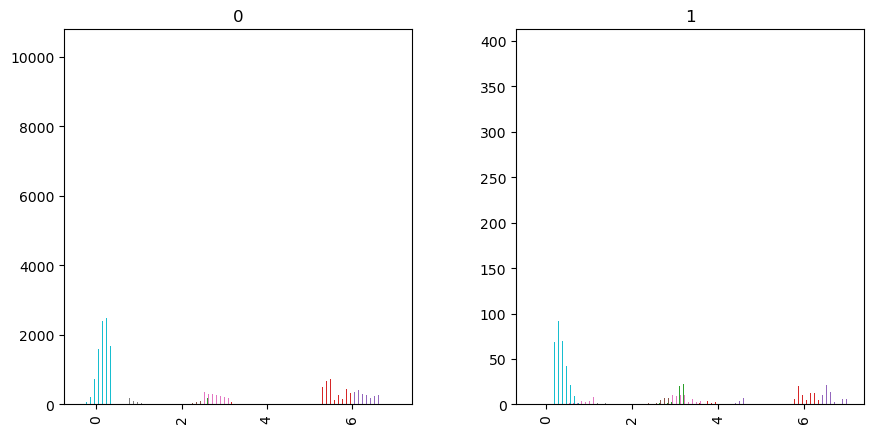

In [75]:
EDA.manifoldEntropy.hist(by='Linked?' ,figsize=[10, 5],bins=80)

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

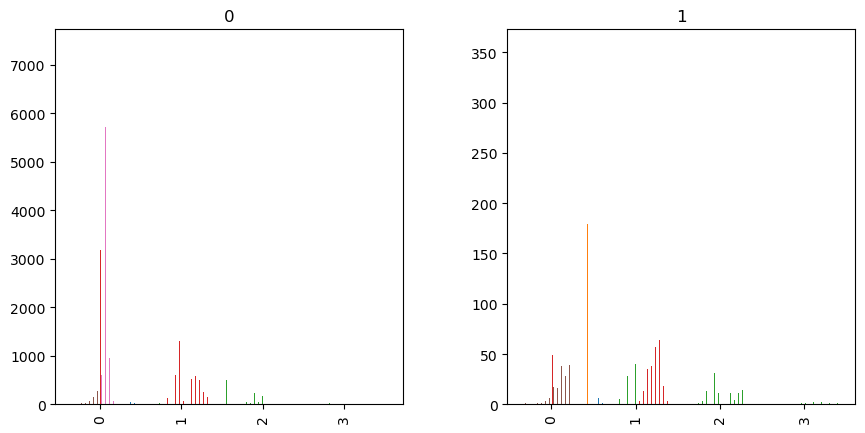

In [76]:
EDA.sharedInfo.hist(by='Linked?' ,figsize=[10, 5],bins=80)

array([[<Axes: title={'center': 'EntropyMetric.Entropy_src'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'EntropyMetric.Entropy_tgt'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'EntropyMetric.JI'}, xlabel='[Linked?]'>],
       [<Axes: title={'center': 'EntropyMetric.Loss'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'EntropyMetric.MI'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'EntropyMetric.Noise'}, xlabel='[Linked?]'>],
       [<Axes: title={'center': 'SimilarityMetric.COS_sim'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'SimilarityMetric.EUC_sim'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'SimilarityMetric.SCM_sim'}, xlabel='[Linked?]'>],
       [<Axes: title={'center': 'SimilarityMetric.WMD_sim'}, xlabel='[Linked?]'>,
        <Axes: >, <Axes: >]], dtype=object)

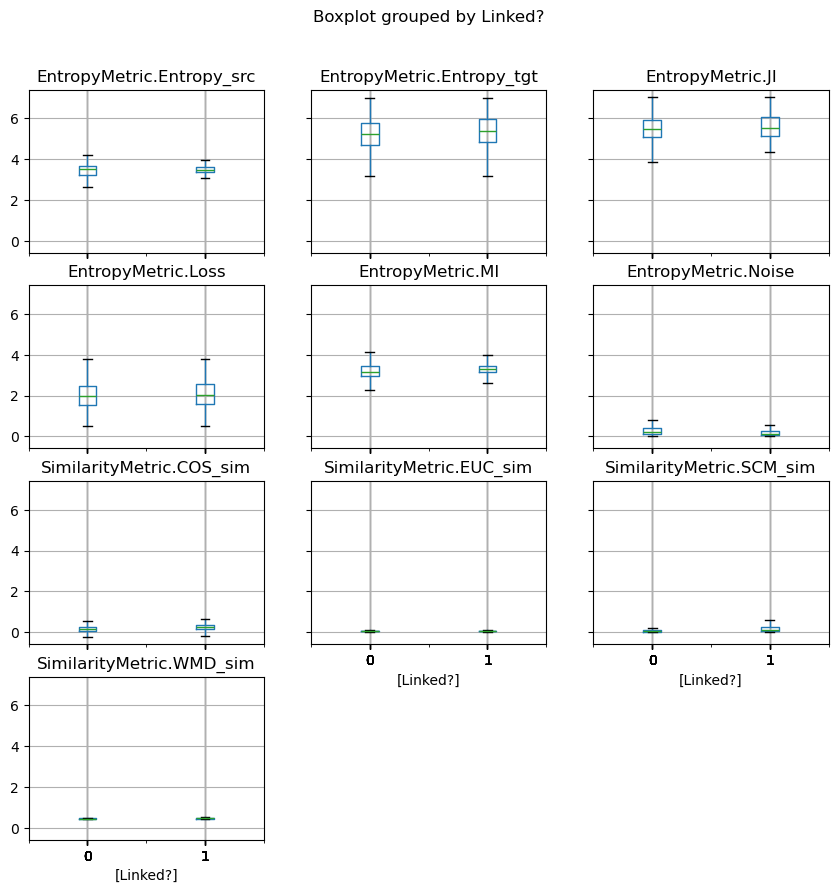

In [77]:
EDA.manifoldEntropy.boxplot(by='Linked?',figsize=[10, 10], showfliers=False) #Without Outliers

array([[<Axes: title={'center': 'EntropyMetric.MSI_I'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'EntropyMetric.MSI_X'}, xlabel='[Linked?]'>],
       [<Axes: title={'center': 'SimilarityMetric.COS_sim'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'SimilarityMetric.EUC_sim'}, xlabel='[Linked?]'>],
       [<Axes: title={'center': 'SimilarityMetric.SCM_sim'}, xlabel='[Linked?]'>,
        <Axes: title={'center': 'SimilarityMetric.WMD_sim'}, xlabel='[Linked?]'>]],
      dtype=object)

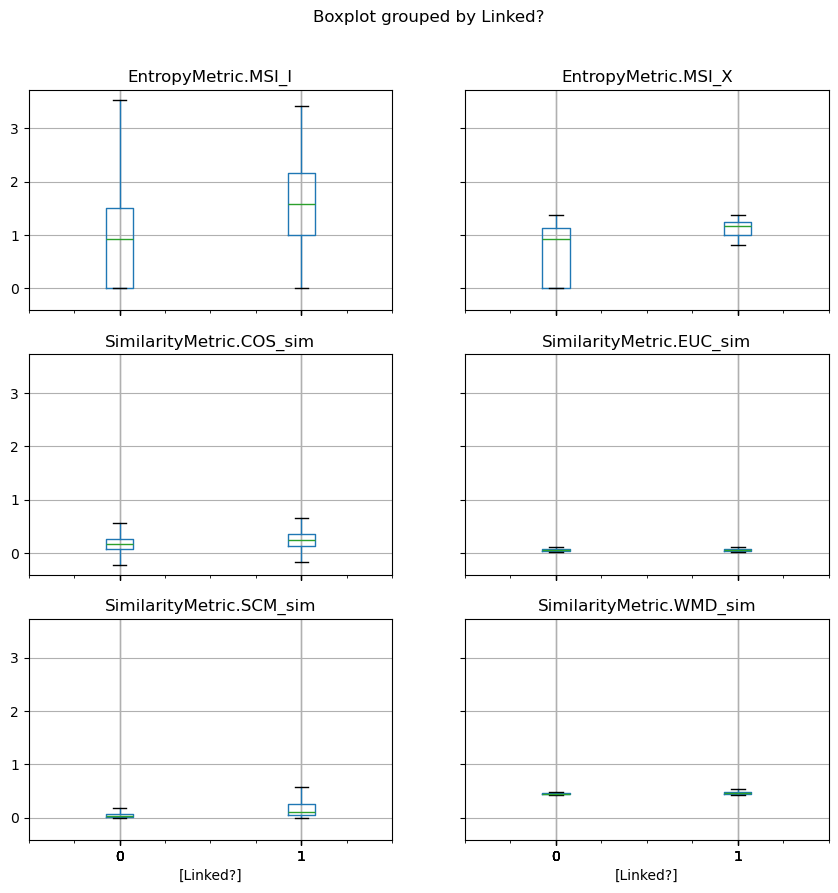

In [78]:
EDA.sharedInfo.boxplot(by='Linked?',figsize=[10, 10], showfliers=False)

### EDA Self Entropy for SACP

In [ ]:
##Max Self Source
EDA.df_w2v[EDA.df_w2v['Target']=='sacp-python-common/setup.py'][['Source','Target','EntropyMetric.Entropy_tgt','Linked?']].values

array([[295, 'sacp-python-common/setup.py', 5.370004292053436, 0.0],
       [294, 'sacp-python-common/setup.py', 5.370004292053436, 0.0],
       [293, 'sacp-python-common/setup.py', 5.370004292053436, 0.0],
       ...,
       [5, 'sacp-python-common/setup.py', 5.370004292053436, 0.0],
       [1, 'sacp-python-common/setup.py', 5.370004292053436, 0.0],
       [2, 'sacp-python-common/setup.py', 5.370004292053436, 0.0]],
      dtype=object)

In [ ]:
EDA.df_w2v[EDA.df_w2v['Source']==193][['Source','Target','EntropyMetric.Entropy_src','EntropyMetric.Entropy_tgt','Linked?']].values

array([[193, 'sacp-python-common/sacp_python_common/auth_utility.py',
        5.095175521464347, 6.301552355933639, 1.0],
       [193, 'sacp-python-common/sacp_python_common/bandit/bandit.py',
        5.095175521464347, 6.7390055040216685, 0.0],
       [193,
        'sacp-python-common/sacp_python_common/bandit/banditReport.py',
        5.095175521464347, 5.870833373337848, 0.0],
       [193, 'sacp-python-common/sacp_python_common/cave/caveCa.py',
        5.095175521464347, 5.371881234145534, 0.0],
       [193, 'sacp-python-common/sacp_python_common/cave/caveSsl.py',
        5.095175521464347, 4.85108279267097, 0.0],
       [193, 'sacp-python-common/sacp_python_common/cave/caveZap.py',
        5.095175521464347, 6.139571208108156, 0.0],
       [193,
        'sacp-python-common/sacp_python_common/csbcicd_report/aggregator.py',
        5.095175521464347, 5.6097106273392585, 0.0],
       [193,
        'sacp-python-common/sacp_python_common/csbcicd_report/csbcicd_func.py',
        5.095175

In [ ]:
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Entropy_tgt']==EDA.df_w2v['EntropyMetric.Entropy_tgt'].quantile(.99)][['Source','Target','EntropyMetric.Entropy_tgt','Linked?']].values

In [ ]:
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Entropy_tgt']==EDA.df_w2v['EntropyMetric.Entropy_tgt'].min()][['Target']].values

array([['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
       ['sacp-python-common/sacp_python_common/template/__init__.py'],
      

In [ ]:
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Entropy_tgt']>=EDA.df_w2v['EntropyMetric.Entropy_tgt'].quantile(.97)][['Source','Target','EntropyMetric.Entropy_tgt','Linked?']].values

array([[295,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.502034948968415, 1.0],
       [295,
        'sacp-python-common/sacp_python_common/third_party/binary_scan_func.py',
        7.4800077110143315, 1.0],
       [295,
        'sacp-python-common/sacp_python_common/third_party/run_ipcentral_automation.py',
        7.450178124335845, 0.0],
       ...,
       [2,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.502034948968415, 0.0],
       [2,
        'sacp-python-common/sacp_python_common/third_party/binary_scan_func.py',
        7.4800077110143315, 0.0],
       [2,
        'sacp-python-common/sacp_python_common/third_party/run_ipcentral_automation.py',
        7.450178124335845, 0.0]], dtype=object)

In [ ]:
## Nan Shared Vectors

In [ ]:
df_nan_msi = EDA.df_w2v[np.isnan(EDA.df_w2v['EntropyMetric.MSI_I'])]

In [ ]:
df_nan_msi

,Source,Target,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?
9,295,sacp-python-common/sacp_python_common/ctsm2csd...,1.230672,0.448295,0.895580,0.104420,NaN,NaN,3.70044,5.768002,5.970172,3.498270,2.269732,0.202170,0.0
11,295,sacp-python-common/sacp_python_common/fireExce...,1.245996,0.445237,0.947094,0.052906,NaN,NaN,3.70044,4.165014,4.892702,2.972751,1.192262,0.727688,0.0
12,295,sacp-python-common/sacp_python_common/gosec/go...,1.230569,0.448316,0.896543,0.103457,NaN,NaN,3.70044,5.449969,5.705801,3.444608,2.005361,0.255832,0.0
17,295,sacp-python-common/sacp_python_common/psb_mapp...,1.283152,0.437991,0.977981,0.022019,NaN,NaN,3.70044,5.945464,6.058440,3.587464,2.358000,0.112976,1.0
21,295,sacp-python-common/sacp_python_common/spotbugs...,1.226556,0.449124,0.910101,0.089899,NaN,NaN,3.70044,4.927561,5.287861,3.340140,1.587422,0.360300,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21250,2,sacp-python-common/sacp_python_common/gosec/go...,1.230569,0.448316,0.896543,0.103457,NaN,NaN,3.70044,5.449969,5.705801,3.444608,2.005361,0.255832,0.0
21255,2,sacp-python-common/sacp_python_common/psb_mapp...,1.283152,0.437991,0.977981,0.022019,NaN,NaN,3.70044,5.945464,6.058440,3.587464,2.358000,0.112976,0.0
21259,2,sacp-python-common/sacp_python_common/spotbugs...,1.226556,0.449124,0.910101,0.089899,NaN,NaN,3.70044,4.927561,5.287861,3.340140,1.587422,0.360300,0.0
21260,2,sacp-python-common/sacp_python_common/template...,1.250766,0.444293,0.943774,0.056226,NaN,NaN,3.70044,2.521641,4.221928,2.000152,0.521488,1.700287,0.0


In [ ]:
df_nan_msi[df_nan_msi['Linked?']==1][['Source','Target','SimilarityMetric.WMD_sim']].to_csv('msi_i_sacp.csv')

### Special Cases SACP

In [ ]:
EDA.df_w2v.head(1)

,Source,Target,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,Linked?
0,295,sacp-python-common/sacp_python_common/auth_uti...,1.226182,0.4492,0.889624,0.110376,1.584963,1.169925,3.70044,6.301552,6.400817,3.601175,2.700378,0.099265,0.0


In [ ]:
EDA.df_sys.head(1)

,ids,text,type,conv
0,295,Production Merge * Feed release name through t...,pr,product merg feed releas name upload bom allow...


In [ ]:
## Edges cases 

In [ ]:
## MAX MSI_I
EDA.df_w2v[EDA.df_w2v['EntropyMetric.MSI_I']==EDA.df_w2v['EntropyMetric.MSI_I'].min()][['Source','Target','EntropyMetric.MSI_I','Linked?']].values[70]

array([292,
       'sacp-python-common/sacp_python_common/harden_check/harden_func.py',
       0.0, 0.0], dtype=object)

In [ ]:
EDA.df_w2v[EDA.df_w2v['EntropyMetric.MSI_I']==EDA.df_w2v['EntropyMetric.MSI_I'].min()][['Source','Target','EntropyMetric.MSI_I','Linked?']].values

In [ ]:
##Max Loss
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Loss']==EDA.df_w2v['EntropyMetric.Loss'].max()][['Source','Target','EntropyMetric.Loss','Linked?']].values

array([[241,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [168,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [144,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [128,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [113,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [101,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        7.505229986653098, 0.0],
       [41,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
     

In [ ]:
EDA.df_sys[EDA.df_sys['ids'] == 'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py']['text'].values

array(['#!/usr/bin/env python3\r\n\r\nimport copy\r\nimport datetime\r\nimport hashlib\r\nimport json\r\nimport logging\r\nimport os\r\nimport sys\r\n\r\nimport boto3\r\n\r\nfrom sacp_python_common.fireException import fireException\r\nfrom sacp_python_common.psb_mapping import scf_psb_mapping\r\n\r\nLOG = logging.getLogger("security_results_push_func")\r\nlogging.basicConfig(stream=sys.stdout, level=logging.INFO)\r\n\r\n# SQS Details\r\nregion = "us-west-2"\r\nq_type = "sqs"\r\naccount_number = "962705020265"\r\nq_name = "audit_aggregator_queue.fifo"\r\nq_url = "https://{}.{}.amazonaws.com/{}/{}".format(\r\n    q_type, region, account_number, q_name\r\n)\r\n\r\n\r\ndef psb_binary(corona_dir=None, bd_dir=None, ipc_dir=None):\r\n    """Calls process binary functions to help add psb test data\r\n    Arguments:\r\n        corona_dir {str} -- Corona directory (default: None)\r\n        bd_dir {str} -- BlackDuck directory (default: None)\r\n        ipc_dir {str} -- IP Central directory (def

In [ ]:
EDA.df_sys[EDA.df_sys['ids'] == '41']['text'].values

array(['Update binary_scan_func.py (#40)  '], dtype=object)

In [ ]:
##Min Loss
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Loss']==EDA.df_w2v['EntropyMetric.Loss'].min()][['Source','Target','EntropyMetric.Loss','Linked?']].values

array([[256, 'sacp-python-common/sacp_python_common/third_party/cve.py',
        -0.010363686453112031, 1.0],
       [56, 'sacp-python-common/sacp_python_common/third_party/cve.py',
        -0.010363686453112031, 0.0]], dtype=object)

In [ ]:
#Quantiles and Links
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Loss']>=EDA.df_w2v['EntropyMetric.Loss'].quantile(.99)][['Source','Target','EntropyMetric.Loss','Linked?']].values

array([[245,
        'sacp-python-common/sacp_python_common/security_results_push/security_results_push_func.py',
        6.506040253005677, 0.0],
       [245,
        'sacp-python-common/sacp_python_common/spotbugs/spotbugs.py',
        6.397075798268375, 0.0],
       [245,
        'sacp-python-common/sacp_python_common/third_party/binary_scan_func.py',
        6.4833488094213125, 0.0],
       [245,
        'sacp-python-common/sacp_python_common/third_party/run_ipcentral_automation.py',
        6.456834777930168, 0.0],
       [241, 'sacp-python-common/sacp_python_common/auth_utility.py',
        6.31055396952745, 0.0],
       [241, 'sacp-python-common/sacp_python_common/bandit/bandit.py',
        6.744945140243513, 0.0],
       [241,
        'sacp-python-common/sacp_python_common/csbcicd_report/csbcicd_func.py',
        7.247384315542133, 1.0],
       [241,
        'sacp-python-common/sacp_python_common/csbcicd_report/csbcicdReport.py',
        6.26266034562971, 0.0],
       [241,
   

In [ ]:
EDA.df_sys[EDA.df_sys['ids'] == '13']['text'].values

array(['BDscan  '], dtype=object)

In [ ]:
EDA.df_sys[EDA.df_sys['ids'] == 'sacp-python-common/sacp_python_common/auth_utility.py']['text'].values

array(['"""\r\nCreated on Aug 12, 2019\r\n\r\n@author: Aniketh Reddy(animalle)\r\n\r\nWrapper for common Cloud SSO API queries.\r\n\r\nUsage: #TODO\r\n\r\n"""\r\nimport json\r\nimport logging\r\nimport os\r\nimport sys\r\n\r\nimport requests\r\n\r\nLOG = logging.getLogger("OAuth-API")\r\nlogging.basicConfig(stream=sys.stdout, level=logging.INFO)\r\n\r\nHERE = os.path.dirname(os.path.realpath(__file__))\r\nsys.path.append(os.path.join(HERE, "vendored"))\r\n\r\n\r\nclass AuthInstance(object):\r\n    """\r\n    classdocs\r\n    """\r\n\r\n    config = dict()\r\n\r\n    def __init__(self, *args):\r\n\r\n        # try:\r\n        self.session = requests.Session()\r\n        self.config["username"] = args[0]\r\n        self.config["password"] = args[1]\r\n        self.config["id"] = "default"\r\n        self.config["secret"] = "default"\r\n        self.token = ""\r\n        self.get_auth_token()\r\n\r\n    def get_auth_token(self):\r\n        base_url = "https://cloudsso.cisco.com/as/token.o

In [ ]:
## Min and Max Noise
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Noise']==EDA.df_w2v['EntropyMetric.Noise'].max()][['Source','Target','EntropyMetric.Noise','Linked?']].values

array([[256,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        4.1179792783376925, 0.0],
       [56, 'sacp-python-common/sacp_python_common/template/__init__.py',
        4.1179792783376925, 0.0]], dtype=object)

In [ ]:
EDA.df_w2v['EntropyMetric.Noise'].quantile(.99)

1.5157605613107932

In [ ]:
#Quantiles and Links
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Noise']>=EDA.df_w2v['EntropyMetric.Noise'].quantile(.99)][['Source','Target','EntropyMetric.Noise','Linked?']].values

array([[295,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        1.7002874585440444, 0.0],
       [294, 'sacp-python-common/sacp_python_common/fireException.py',
        2.2292087682910897, 0.0],
       [294,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        3.677755327808581, 0.0],
       [294,
        'sacp-python-common/sacp_python_common/third_party/ipcReport.py',
        1.687583117712168, 0.0],
       [294, 'sacp-python-common/sacp_python_common/webex_send_func.py',
        1.7173152013339648, 0.0],
       [294,
        'sacp-python-common/test/python/third_party/test_corona_lite.py',
        1.5983847204931054, 0.0],
       [293, 'sacp-python-common/sacp_python_common/fireException.py',
        1.6610816146294578, 0.0],
       [293,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        2.977941830286627, 0.0],
       [287,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        2.

In [ ]:
EDA.df_w2v[EDA.df_w2v['EntropyMetric.Noise']==EDA.df_w2v['EntropyMetric.Noise'].min()][['Source','Target','EntropyMetric.Noise','Linked?']].values

array([[213, 'sacp-python-common/setup.py', -0.4446231162933376, 0.0],
       [13, 'sacp-python-common/setup.py', -0.4446231162933376, 0.0]],
      dtype=object)

In [ ]:
##MaxMin Mutual Information
EDA.df_w2v[EDA.df_w2v['EntropyMetric.MI']==EDA.df_w2v['EntropyMetric.MI'].min()][['Source','Target','EntropyMetric.MI','Linked?']].values

array([[241,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [168,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [144,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [128,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [113,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [101,
        'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0],
       [41, 'sacp-python-common/sacp_python_common/template/__init__.py',
        -0.2283593636566814, 0.0]], dtype=object)

In [ ]:
#Quantiles and Links
EDA.df_w2v[EDA.df_w2v['EntropyMetric.MI']>=EDA.df_w2v['EntropyMetric.MI'].quantile(.9999)][['Source','Target','EntropyMetric.MI','Linked?']].values

array([[256,
        'sacp-python-common/sacp_python_common/spotbugs/spotbugs.py',
        6.3096323256651745, 0.0],
       [256,
        'sacp-python-common/sacp_python_common/third_party/binary_scan_func.py',
        6.37898030507055, 1.0],
       [56, 'sacp-python-common/sacp_python_common/spotbugs/spotbugs.py',
        6.3096323256651745, 0.0],
       [56,
        'sacp-python-common/sacp_python_common/third_party/binary_scan_func.py',
        6.37898030507055, 0.0]], dtype=object)

In [ ]:
EDA.df_sys[EDA.df_sys['ids'] == '13']['text'].values

array(['BDscan  '], dtype=object)

## Supervised Evaluation

In [81]:
#export
class SupervisedVectorEvaluation(VectorEvaluation):

    def __init__(self, params):
        super().__init__(params)
        
        #Word2vec
        similarities_w2v = self.sim_list_w2v + ['Linked?']
        similarities_w2v = [str(i) for i in similarities_w2v]
        self.df_filtered_w2v = self.df_w2v.copy()
        self.df_filtered_w2v = self.df_filtered_w2v[similarities_w2v] 
        self.df_filtered_w2v = self.df_filtered_w2v[~self.df_filtered_w2v.isin([np.nan, np.inf, -np.inf]).any(axis=1)]
        
        #Doc2vec
        similarities_d2v = self.sim_list_d2v + ['Linked?']
        similarities_d2v = [str(i) for i in similarities_d2v]
        self.df_filtered_d2v = self.df_d2v.copy() 
        self.df_filtered_d2v = self.df_filtered_d2v[similarities_d2v]
        self.df_filtered_d2v = self.df_filtered_d2v[~self.df_filtered_d2v.isin([np.nan, np.inf, -np.inf]).any(axis=1)]

        pass
    
    def vecTypeVerification(self, vecType= VectorizationType.word2vec):
        if vecType == VectorizationType.word2vec:
            self.sim_list = self.sim_list_w2v
            y_test = self.df_filtered_w2v['Linked?'].values
            y_score = [self.df_filtered_w2v[ str(sim) ].values for sim in self.sim_list]
            logging.info('Vectorization: ' +  str(vecType) )
        elif vecType == VectorizationType.doc2vec:
            self.sim_list = self.sim_list_d2v
            y_test = self.df_filtered_d2v['Linked?'].values
            y_score = [self.df_filtered_d2v[ str(sim) ].values for sim in self.sim_list]
            logging.info('Vectorization: ' +  str(vecType) )
        return y_test,y_score
    
    def Compute_precision_recall_gain(self, vecType = VectorizationType.word2vec):
        '''One might choose PRG if there is little interest in identifying false negatives '''
        y_test,y_score = self.vecTypeVerification(vecType=vecType)    
        
        for count,sim in enumerate(self.sim_list):
            prg_curve = prg.create_prg_curve(y_test, y_score[count])
            auprg = prg.calc_auprg(prg_curve)
            prg.plot_prg(prg_curve)
            logging.info('auprg:  %.3f' %  auprg)
            logging.info("compute_precision_recall_gain Complete: "+str(sim))
        pass
    
    def Compute_avg_precision(self, vecType = VectorizationType.word2vec):
        '''Generated precision-recall curve enhanced'''
        y_test,y_score = self.vecTypeVerification(vecType=vecType)
        
        linestyles = ['solid','dashed','dashdot','dotted']
        
        fig, ax1 = plt.subplots(figsize=(8, 6))
        
        ax1.grid(True)
        #ax1.yaxis.grid(color='gray', linestyle='dashed')
        
        color = 'tab:red'
        ax1.set_xlabel('recall [fpr]')
        ax1.set_ylabel('precision', color=color)
        
        # calculate the no skill line as the proportion of the positive class
        no_skill = len(y_test[y_test==1]) / len(y_test)
        ax1.plot([0, 1], [no_skill, no_skill], color=color, linewidth=0.5, linestyle='dotted', label='No Skill [{0:0.2f}]'.format(no_skill)) #reference curve
        
        for count,sim in enumerate(self.sim_list):
            precision, recall, _ = precision_recall_curve(y_test, y_score[count]) #compute precision-recall curve
            average_precision = average_precision_score(y_test, y_score[count])
            auc_score = auc(recall, precision)
            logging.info('Average precision-recall score: {0:0.2f}'.format(average_precision))
            logging.info('Precision-Recall AUC: %.2f' % auc_score)
            
            #plt.plot(recall, precision, linewidth=0.4, marker='.', label = str(sim)) #plot model curve
            ax1.plot(recall, precision, color=color, linewidth=1, linestyle=linestyles[count], label = str(sim.name)+' [auc:{0:0.2f}]'.format(auc_score)) #plot model curve
            
            pass     
        
        ax1.tick_params(axis='y', labelcolor=color) #Color of the axis value
        
        
        ##AUC
        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        
        color = 'tab:blue'
        ax2.set_ylabel('tpr', color=color)  # we already handled the x-label with ax1
        
        ax2.plot([0, 1], [0, 1], color=color,  linewidth=0.5, linestyle='dotted', label='No Skill') #reference curve
        for count,sim in enumerate(self.sim_list):
            fpr, tpr, _ = roc_curve(y_test, y_score[count]) #compute roc curve
            roc_auc = roc_auc_score(y_test, y_score[count])
            logging.info('ROC AUC %.2f' % roc_auc)
            
            ax2.plot(fpr, tpr, color=color, linewidth=1, linestyle=linestyles[count], label = str(sim.name)+ ' [auc:{0:0.2f}]'.format(roc_auc)) #plot model curve
            pass   
        
        ax2.tick_params(axis='y', labelcolor=color) #Color of the axis value
        
        ##Design
        ax1.legend(loc='upper center',ncol=3, fontsize= 'small')
        ax2.legend(loc='lower center',ncol=3, fontsize= 'small')
        
        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        
        #plt.set_axisbelow(True)
        #plt.yaxis.grid(color='gray', linestyle='dashed')
        
        plt.title( params['system'] + "-[" + str(vecType) + "]")
        plt.show() #show the plot
        pass
    
    def __Compute_avg_precision_same_plot(self, vecType = VectorizationType.word2vec):
        '''Generated precision-recall curve'''

        y_test,y_score = self.vecTypeVerification(vecType=vecType)
        
        # calculate the no skill line as the proportion of the positive class
        no_skill = len(y_test[y_test==1]) / len(y_test)
        plt.plot([0, 1], [no_skill, no_skill], linewidth=0.5, linestyle='--', label='No Skill [{0:0.2f}]'.format(no_skill)) #reference curve
        
        for count,sim in enumerate(self.sim_list):
            precision, recall, _ = precision_recall_curve(y_test, y_score[count]) #compute precision-recall curve
            average_precision = average_precision_score(y_test, y_score[count])
            auc_score = auc(recall, precision)
            logging.info('Average precision-recall score: {0:0.2f}'.format(average_precision))
            logging.info('Precision-Recall AUC: %.2f' % auc_score)
            
            #plt.plot(recall, precision, linewidth=0.4, marker='.', label = str(sim)) #plot model curve
            plt.plot(recall, precision, linewidth=1, label = str(sim)+ ' [auc:{0:0.2f}]'.format(auc_score)) #plot model curve
            pass
        
        plt.title(str(vecType))
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.legend(fontsize=9) #show the legend
        plt.show() #show the plot
        pass
    
    def __Compute_roc_curve(self, vecType = VectorizationType.word2vec):
        
        y_test,y_score = self.vecTypeVerification(vecType = vecType)

        plt.plot([0, 1], [0, 1],  linewidth=0.5, linestyle='--', label='No Skill') #reference curve
        
        for count,sim in enumerate(self.sim_list):
            fpr, tpr, _ = roc_curve(y_test, y_score[count]) #compute roc curve
            roc_auc = roc_auc_score(y_test, y_score[count])
            logging.info('ROC AUC %.2f' % roc_auc)
            
            plt.plot(fpr, tpr,  linewidth=1, label = str(sim)+  ' [auc:{0:0.2f}]'.format(roc_auc)) #plot model curve
            pass
        plt.title(str(vecType))
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(fontsize=9) #show the legend
        plt.show() #show the plot

        pass
    
    def CofusionMatrix(self, vecType = VectorizationType.word2vec):
        ##TODO This implementatin is incomplete and not verify it yet
        y_test,y_score = self.vecTypeVerification(vecType=vecType)
        y_score_threshold = [0 if elem<=0.8 else 1 for elem in supevisedEval.y_score] #Hardcoded 0.7 Threshold
        #TODO a Variation threshold analysis
        tn, fp, fn, tp = confusion_matrix(supevisedEval.y_test, y_score_threshold).ravel()
        return tn, fp, fn, tp

## Plotting

In [82]:
#params = sacp_params()
#params = libest_params()

In [83]:
supevisedEval = SupervisedVectorEvaluation(params = params) #<---- Parameter 

In [84]:
supevisedEval.df_w2v.head(2)

,Target,DistanceMetric.WMD,SimilarityMetric.WMD_sim,DistanceMetric.SCM,SimilarityMetric.SCM_sim,EntropyMetric.MSI_I,EntropyMetric.MSI_X,EntropyMetric.Entropy_src,EntropyMetric.Entropy_tgt,EntropyMetric.JI,EntropyMetric.MI,EntropyMetric.Loss,EntropyMetric.Noise,SourceFile,TargetFile,Linked?
Source,,,,,,,,,,,,,,,,
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,/Users/loganfecko/Desktop/Summer_Research/trac...,1.235760,0.447275,0.951526,0.048474,1.921928,1.214807,3.773557,6.141791,6.213403,3.701945,2.439846,0.071612,RE-616.txt,FullMissionPlan.java,0
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,/Users/loganfecko/Desktop/Summer_Research/trac...,1.269806,0.440566,1.000000,0.000000,NaN,NaN,3.773557,5.446458,5.689563,3.530453,1.916006,0.243105,RE-616.txt,JSONMissionPlanReader.java,0


In [85]:
supevisedEval.df_d2v.head(2)

,Target,DistanceMetric.EUC,SimilarityMetric.EUC_sim,DistanceMetric.COS,SimilarityMetric.COS_sim,DistanceMetric.MAN,SimilarityMetric.MAN_sim,Linked?
Source,,,,,,,,
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,/Users/loganfecko/Desktop/Summer_Research/trac...,23.332077,0.041098,0.968829,0.031171,414.29510,0.002408,0
/Users/loganfecko/Desktop/Summer_Research/traceXplainer/dvc-data/systems/dronology/corpus/req/RE-616.txt,/Users/loganfecko/Desktop/Summer_Research/trac...,19.919678,0.047802,0.857385,0.142615,350.02527,0.002849,0


In [86]:
supevisedEval.df_filtered_w2v.size

32016

In [87]:
supevisedEval.df_w2v.size

170752

In [88]:
supevisedEval.df_w2v[ 'Linked?' ].values

array([0, 0, 0, ..., 0, 0, 0])

In [89]:
[k for k in supevisedEval.df_w2v[ 'Linked?' ].values if k == 1]

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [90]:
y_test,y_score = supevisedEval.vecTypeVerification(VectorizationType.word2vec)

2025-07-14 07:52:04,163 : INFO : Vectorization: VectorizationType.word2vec


In [91]:
y_test,y_score = supevisedEval.vecTypeVerification(VectorizationType.doc2vec)

2025-07-14 07:52:05,047 : INFO : Vectorization: VectorizationType.doc2vec


In [92]:
[k for k in y_test if k == 1]

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


### 1. Compute the average precision score and Compute ROC Curve
Precision is a metric that quantifies the number of correct positive predictions made.

Recall is a metric that quantifies the number of correct positive predictions made out of all positive predictions that could have been made.

An ROC curve (or receiver operating characteristic curve) is a plot that summarizes the performance of a binary classification model on the positive class [(see Blog)](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-imbalanced-classification/).

Use ROC when both classes detection is equally important — When we want to give equal weight to both classes prediction ability we should look at the ROC curve [link](https://towardsdatascience.com/what-metrics-should-we-use-on-imbalanced-data-set-precision-recall-roc-e2e79252aeba).

2025-07-14 07:52:08,627 : INFO : Vectorization: VectorizationType.word2vec
2025-07-14 07:52:08,664 : INFO : Average precision-recall score: 0.17
2025-07-14 07:52:08,664 : INFO : Precision-Recall AUC: 0.16
2025-07-14 07:52:08,671 : INFO : Average precision-recall score: 0.13
2025-07-14 07:52:08,671 : INFO : Precision-Recall AUC: 0.13
2025-07-14 07:52:08,687 : INFO : ROC AUC 0.75
2025-07-14 07:52:08,693 : INFO : ROC AUC 0.71


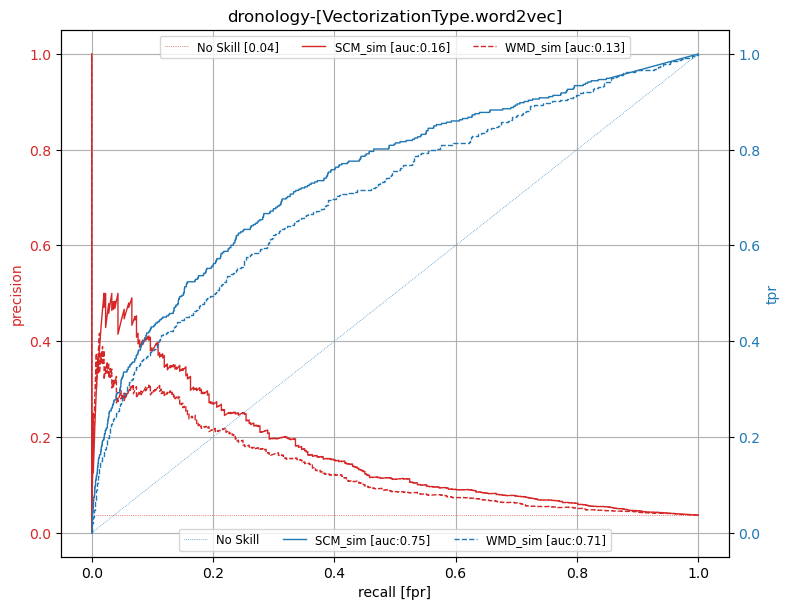

In [93]:
supevisedEval.Compute_avg_precision(VectorizationType.word2vec)

2025-07-14 07:52:15,444 : INFO : Vectorization: VectorizationType.doc2vec
2025-07-14 07:52:15,468 : INFO : Average precision-recall score: 0.09
2025-07-14 07:52:15,469 : INFO : Precision-Recall AUC: 0.09
2025-07-14 07:52:15,475 : INFO : Average precision-recall score: 0.04
2025-07-14 07:52:15,475 : INFO : Precision-Recall AUC: 0.04
2025-07-14 07:52:15,489 : INFO : ROC AUC 0.65
2025-07-14 07:52:15,494 : INFO : ROC AUC 0.48


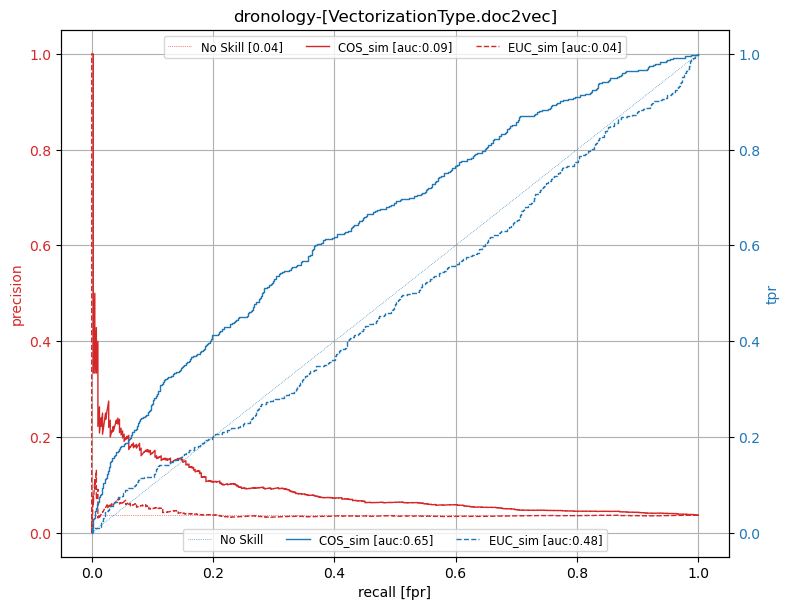

In [94]:
supevisedEval.Compute_avg_precision(VectorizationType.doc2vec)

### 2. Precision-Racall-Gain
Based on the library here: [link](https://github.com/meeliskull/prg/tree/master/Python_package). 
The area under traditional PR curves can easily favour models with lower expected F1 score than others, and so the use of Precision-Recall-Gain curves will result in better model selection [(Flach & Kull, 2015)](http://people.cs.bris.ac.uk/~flach//PRGcurves/).
One might choose PRG if there is little interest in identifying false negatives [(from Blog)](https://medium.com/@alexabate/i-did-something-boring-so-you-dont-have-to-9140ca46c84d).

In [95]:
supevisedEval.Compute_precision_recall_gain(VectorizationType.word2vec)

2025-07-14 07:52:19,061 : INFO : Vectorization: VectorizationType.word2vec


NameError: name 'prg' is not defined

2021-01-13 04:22:37,440 : INFO : Vectorization: VectorizationType.doc2vec


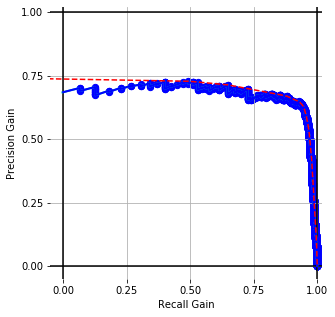

2021-01-13 04:22:37,811 : INFO : auprg:  0.676
2021-01-13 04:22:37,812 : INFO : compute_precision_recall_gain Complete: SimilarityMetric.COS_sim


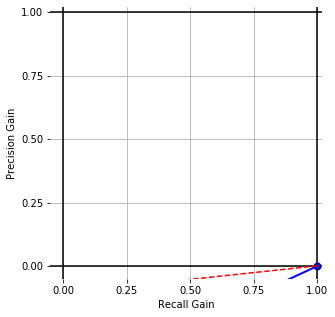

2021-01-13 04:22:38,074 : INFO : auprg:  -0.326
2021-01-13 04:22:38,075 : INFO : compute_precision_recall_gain Complete: SimilarityMetric.EUC_sim


In [ ]:
supevisedEval.Compute_precision_recall_gain(VectorizationType.doc2vec)

In [ ]:
SimilarityMetric.WMD_sim.name

'WMD_sim'

## Manifold Entropy Plots

In [ ]:
#export
class ManifoldEntropy(VectorEvaluation):
    def __init__(self, params):
        super().__init__(params)
        self.sharedEntropy_filtered = self.sharedInfo.copy()
        self.sharedEntropy_filtered.dropna(inplace=True)
        pass
    
    def minimum_shared_entropy(self,dist = SimilarityMetric.WMD_sim, extropy=False):
        '''Minimum Shared Plot'''
        ent = EntropyMetric.MSI_I
        color = 'DarkBlue'
        if extropy:
            ent = EntropyMetric.MSI_X
            color = 'Red'
        columns = [str(i) for i in [ent, dist ]]
        
        x1 = self.sharedEntropy_filtered.plot.scatter(
            x = columns[0],
            y = columns[1], 
            c = color, 
            s = 1,
            title = params['system']+': ['+ dist.name + '-' + ent.name + '] Correlation {%.2f}' % self.compute_spearman_corr(
                self.sharedEntropy_filtered, columns)
        )
        pass
    
    def manifold_entropy_plot(self, manifold = EntropyMetric.MI, dist = SimilarityMetric.WMD_sim):
        '''Manifold Entropy'''
        
        columns = [str(i) for i in [manifold, dist]]
        
        x1 = self.manifoldEntropy.plot.scatter(
            x = columns[0],
            y = columns[1], 
            c = 'DarkBlue', 
            s = 1,
            title = params['system']+': ['+ dist.name + '-' + manifold.name + '] Correlation {%.2f}' % self.compute_spearman_corr(
                self.manifoldEntropy, columns)
        )
        pass
    
    def composable_entropy_plot(self, 
                                manifold_x = EntropyMetric.MI,
                                manifold_y = EntropyMetric.Loss,
                                dist = SimilarityMetric.WMD_sim 
                               ):
    
        columns = [str(i) for i in [manifold_x, manifold_y, dist]]
        fig, ax = plt.subplots()
        self.manifoldEntropy.plot.scatter(
            x = columns[0],
            y = columns[1],
            c = columns[2],
            #figsize = [12, 6],
            title = params['system']+': Information-Semantic Interactions '+ dist.name ,
            colormap = 'viridis',
            ax = ax,
            s=1
        )
        ax.set_xlabel( columns[0] )
        ax.set_ylabel( columns[1] )    
        pass
    
    def compute_spearman_corr(self, filter_metrics_01, columns):
        df_correlation = filter_metrics_01.copy() 
        correlation = df_correlation[columns].corr(method='spearman')
        #correlation = df_correlation.corr(method='spearman')
        return correlation[columns[0]].values[1]

In [ ]:
manifoldEntropy = ManifoldEntropy(params = params) 

### Minimum Shared Entropy and Distances

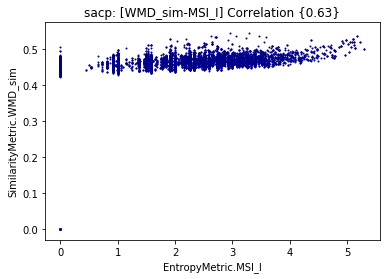

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.WMD_sim)

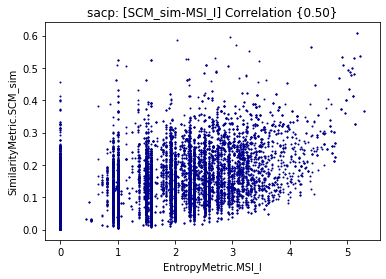

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.SCM_sim)

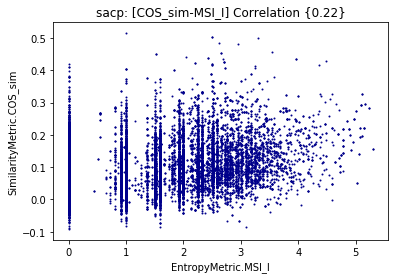

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.COS_sim)

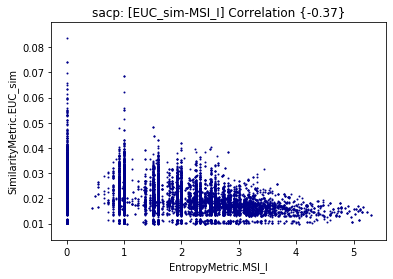

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.EUC_sim)

### Minimum Shared Extropy and Distances

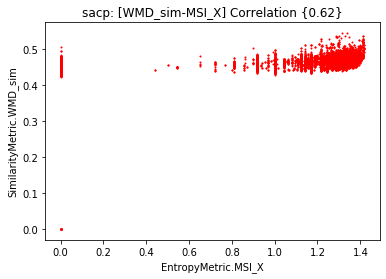

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.WMD_sim, extropy=True)

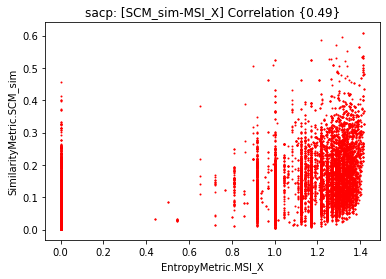

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.SCM_sim, extropy=True)

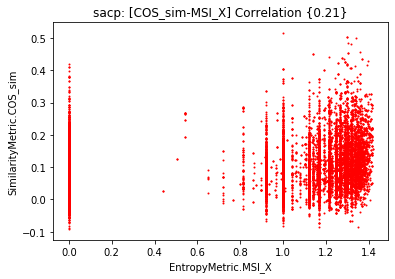

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.COS_sim, extropy=True)

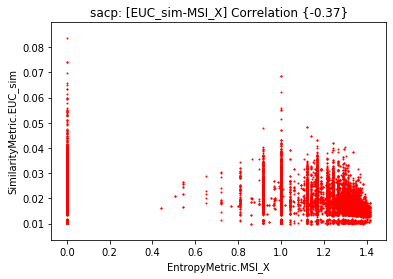

In [ ]:
manifoldEntropy.minimum_shared_entropy(dist=SimilarityMetric.EUC_sim, extropy=True)

### Mutual Information and Distance

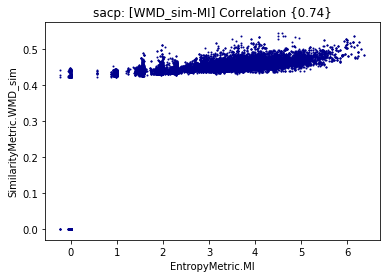

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.MI, dist = SimilarityMetric.WMD_sim)

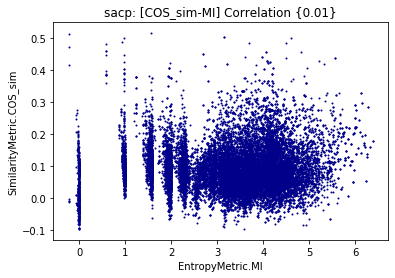

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.MI, dist = SimilarityMetric.COS_sim)

### Loss Information and Distance

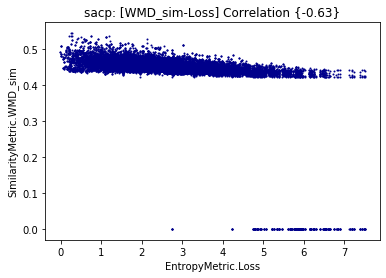

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Loss, dist = SimilarityMetric.WMD_sim)

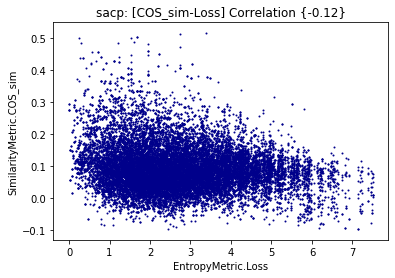

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Loss, dist = SimilarityMetric.COS_sim)

### Noise Information and Distance

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Noise, dist = SimilarityMetric.WMD_sim)

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Noise, dist = SimilarityMetric.COS_sim)

### Self-Information

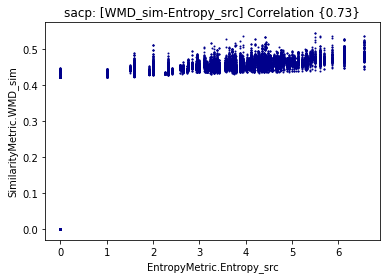

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Entropy_src, dist = SimilarityMetric.WMD_sim)

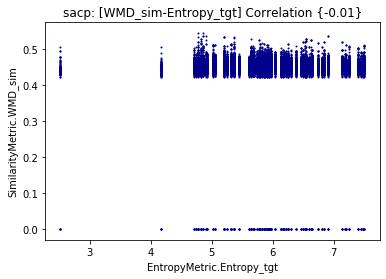

In [ ]:
manifoldEntropy.manifold_entropy_plot(manifold = EntropyMetric.Entropy_tgt, dist = SimilarityMetric.WMD_sim)

## Composable Manifolds

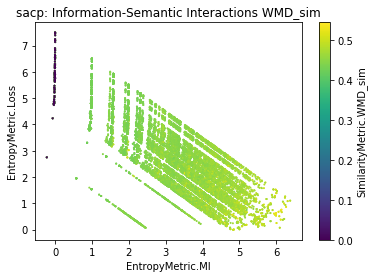

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = EntropyMetric.Loss,
                        dist = SimilarityMetric.WMD_sim )

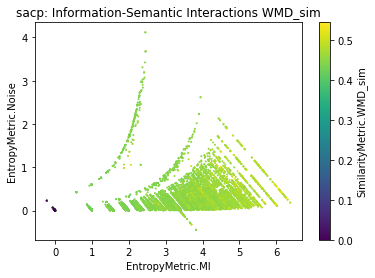

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = EntropyMetric.Noise,
                        dist = SimilarityMetric.WMD_sim )

### Grouping Mutual information & Similarity Thru Noise

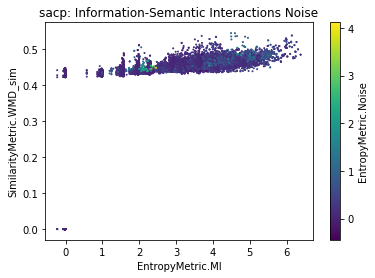

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = SimilarityMetric.WMD_sim,
                        dist = EntropyMetric.Noise )

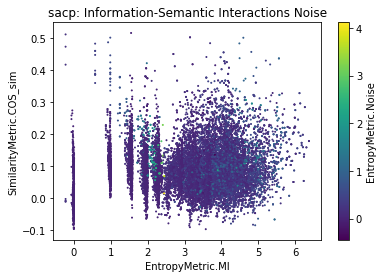

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = SimilarityMetric.COS_sim,
                        dist = EntropyMetric.Noise )

### Grouping Mutual information & Similarity Thru Loss

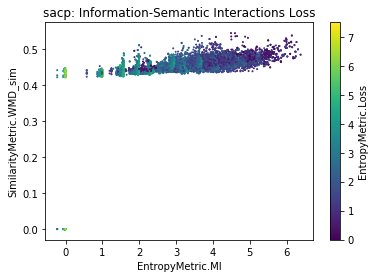

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = SimilarityMetric.WMD_sim,
                        dist = EntropyMetric.Loss )

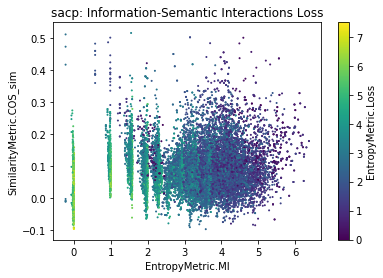

In [ ]:
manifoldEntropy.composable_entropy_plot(
                        manifold_x = EntropyMetric.MI,
                        manifold_y = SimilarityMetric.COS_sim,
                        dist = EntropyMetric.Loss )

In [ ]:
###Deprecated code down!

In [ ]:
filter_metrics_linked = filter_metrics_01[filter_metrics_01['Linked?'] == 1].copy()
filter_metrics_nonlinked = filter_metrics_01[filter_metrics_01['Linked?'] == 0].copy()


In [ ]:
x2 = filter_metrics_01[filter_metrics_01['Linked?'] == 1].plot.scatter(
    x=EntropyMetric.MSI_I,
    y=SimilarityMetric.SCM_sim, 
    c='Red',
    s=1,
    title = 'Liked SCM-Entropy Correlation {%.2f}' % compute_spearman_corr(filter_metrics_linked)
)
#x2.text(0,0,'test')

In [ ]:
#Separated by ground truth Links!
fig, ax = plt.subplots()
filter_metrics_01[filter_metrics_01['Linked?'] == 1].plot.scatter(
    x = EntropyMetric.MSI_I,
    y = EntropyMetric.MSI_X,
    c = SimilarityMetric.SCM_sim,
    #figsize = [12, 6],
    title = 'Information-Semantic Interactions SCM Linked',
    colormap = 'viridis',
    ax = ax,
    s=1
)
ax.set_xlabel("Minimum Shared Entropy")
ax.set_ylabel("Minimum Shared Extropy")

In [ ]:
#Separated by ground truth NonLinked!
fig, ax = plt.subplots()
filter_metrics_01[filter_metrics_01['Linked?'] == 0].plot.scatter(
    x = EntropyMetric.MSI_I,
    y = EntropyMetric.MSI_X,
    c = SimilarityMetric.SCM_sim,
    #figsize = [6, 5],
    title = 'Information-Semantic Interactions SCM non-Linked',
    colormap = 'viridis',
    ax = ax,
    s=1
)

ax.set_xlabel("Minimum Shared Entropy")
ax.set_ylabel("Minimum Shared Extropy")

### Deployment

In [ ]:
! nbdev_build_docs #<-------- [Activate when stable]

In [ ]:
! nbdev_build_lib

In [ ]:
from nbdev.export import notebook2script
notebook2script()

In [ ]:
#! pip install -e .